In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

### STEP 1: 데이터 로드 및 전처리 검증

In [2]:
# 데이터 로드
df_merged = pd.read_csv('df_merged.csv')
y_targets = pd.read_csv('y_targets.csv')

# 기본 정보
months = df_merged['month'].values
scenarios = df_merged['scenario'].values

In [3]:
# 전처리 검증 1: 데이터 누수 체크
print("\n[전처리 검증 1] 데이터 누수 체크")
dangerous_features = ['Leaf_ExtractionYield', 'Root_ExtractionYield']
safe_to_use = True

for feat in dangerous_features:
    if feat in df_merged.columns:
        print(f"⚠️ 위험 특성 발견: {feat}")
        safe_to_use = False

if safe_to_use:
    print("✅ 데이터 누수 없음 - 안전")


[전처리 검증 1] 데이터 누수 체크
⚠️ 위험 특성 발견: Leaf_ExtractionYield
⚠️ 위험 특성 발견: Root_ExtractionYield


In [4]:
# 전처리 검증 2: 타겟 분포 확인
print("\n[전처리 검증 2] 타겟 분포 확인")
for col in y_targets.columns:
    print(f"{col}: mean={y_targets[col].mean():.3f}, std={y_targets[col].std():.3f}")


[전처리 검증 2] 타겟 분포 확인
Leaf_TPC: mean=7.708, std=0.507
Root_TPC: mean=5.147, std=0.550
Leaf_TFC: mean=4.670, std=2.575
Root_TFC: mean=0.605, std=0.136


### 특성 엔지니어링 (도메인 지식 + 그래프 인사이트 반영)

In [5]:
# 기본 특성 선택 (ExtractionYield 제외)
environmental = ['CO2ppm', 'Temp', 'Humid', 'VPD']  # 환경
physiological = ['Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car']  # 생리
fluorescence = ['ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']  # 형광

base_features = environmental + physiological + fluorescence

In [6]:
# 안전한 특성만 선택
X = pd.DataFrame()
for feat in base_features:
    if feat in df_merged.columns:
        X[feat] = df_merged[feat]

print(f"기본 특성 수: {X.shape[1]}")

기본 특성 수: 18


In [7]:
# 1. 천궁 생육 단계 (도메인 지식)
growth_stage_map = {5: 1, 6: 2, 7: 3, 8: 4, 9: 5}
X['growth_stage'] = [growth_stage_map[m] for m in months]
X['growth_stage_squared'] = X['growth_stage'] ** 2
print("  ✓ 생육 단계 (growth_stage)")

  ✓ 생육 단계 (growth_stage)


In [8]:
# 2. 시나리오 정보 (중요!)
X['is_SSP1'] = (scenarios == 'SSP1').astype(int)
X['is_SSP3'] = (scenarios == 'SSP3').astype(int)
X['is_SSP5'] = (scenarios == 'SSP5').astype(int)
print("  ✓ 시나리오 원핫 인코딩")

  ✓ 시나리오 원핫 인코딩


In [9]:
# 3. 온도 관련 특성 (그래프에서 Temp가 가장 중요)
X['temp_stress'] = np.abs(X['Temp'] - 22)  # 최적 온도와의 차이
X['temp_squared'] = X['Temp'] ** 2
X['temp_category'] = pd.cut(X['Temp'], bins=3, labels=[0, 1, 2]).astype(int)
print("  ✓ 온도 관련 특성 3개")

  ✓ 온도 관련 특성 3개


In [10]:
# 4. VPD 스트레스 (두 번째로 중요)
X['vpd_stress'] = np.where(X['VPD'] > 1.5, X['VPD'] - 1.5, 0)
X['vpd_category'] = pd.cut(X['VPD'], bins=3, labels=[0, 1, 2]).astype(int)
print("  ✓ VPD 스트레스 지표")

  ✓ VPD 스트레스 지표


In [11]:
# 5. 광합성 효율 지표
X['photosynthesis_efficiency'] = X['PI_abs'] / (X['PI_abs'].max() + 1e-10)
X['energy_dissipation'] = X['Dio-RC'] / (X['ABS-RC'] + 1e-10)
X['electron_transport'] = X['Eto-RC'] / (X['Tro-RC'] + 1e-10)
print("  ✓ 광합성 효율 지표 3개")

  ✓ 광합성 효율 지표 3개


In [12]:
# 6. 시나리오별 온도 상호작용 (핵심!)
X['temp_x_ssp1'] = X['Temp'] * X['is_SSP1']
X['temp_x_ssp3'] = X['Temp'] * X['is_SSP3']
X['temp_x_ssp5'] = X['Temp'] * X['is_SSP5']
print("  ✓ 시나리오-온도 상호작용")


  ✓ 시나리오-온도 상호작용


In [13]:
# 7. 월별 순환 인코딩
X['month_sin'] = np.sin(2 * np.pi * months / 12)
X['month_cos'] = np.cos(2 * np.pi * months / 12)
print("  ✓ 월별 순환 인코딩")

print(f"\n최종 특성 수: {X.shape[1]}")

  ✓ 월별 순환 인코딩

최종 특성 수: 36


### 통합 모델 (전략 1)

In [14]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y_targets, test_size=0.2, random_state=42, stratify=scenarios
)

In [15]:
# 스케일링
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# 평가 함수
def evaluate_model(y_true, y_pred):
    """공모전 요구 평가 지표 계산"""
    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }
    
    # MSLE, RMSLE
    y_true_pos = np.maximum(y_true, 1e-10)
    y_pred_pos = np.maximum(y_pred, 1e-10)
    metrics['MSLE'] = np.mean((np.log1p(y_true_pos) - np.log1p(y_pred_pos))**2)
    metrics['RMSLE'] = np.sqrt(metrics['MSLE'])
    
    # 상관계수
    if len(y_true.shape) > 1:
        correlations = []
        for i in range(y_true.shape[1]):
            corr = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]
            correlations.append(corr)
        metrics['R'] = np.mean(correlations)
    else:
        metrics['R'] = np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]
    
    return metrics


In [17]:
# 모델별 성능 비교
models = {
    'Ridge': Ridge(alpha=10.0),
    'RF': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    'GB': GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42),
    'XGB': xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42),
    'LGB': lgb.LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1)
}

global_results = {}

for name, model in models.items():
    # MultiOutputRegressor로 래핑
    from sklearn.multioutput import MultiOutputRegressor
    multi_model = MultiOutputRegressor(model)
    
    # 학습
    multi_model.fit(X_train_scaled, y_train)
    
    # 예측
    y_pred = multi_model.predict(X_test_scaled)
    
    # 평가
    metrics = evaluate_model(y_test.values, y_pred)
    global_results[name] = metrics
    
    print(f"{name}: MAE={metrics['MAE']:.4f}, R²={metrics['R2']:.4f}")

Ridge: MAE=0.2799, R²=0.8380
RF: MAE=0.0558, R²=0.9773
GB: MAE=0.0568, R²=0.9736
XGB: MAE=0.0603, R²=0.9645
LGB: MAE=0.0569, R²=0.9794


### 시나리오별 모델 (전략 2)

In [18]:
scenario_models = {}
scenario_results = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n{scenario}:")
    
    # 시나리오별 데이터
    scenario_mask = scenarios == scenario
    X_scenario = X[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    # 분할
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_scenario, y_scenario, test_size=0.2, random_state=42
    )
    
    # 스케일링
    scaler_s = RobustScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled = scaler_s.transform(X_test_s)
    
    # 최적 모델 선택 (GB or RF)
    if scenario == 'SSP5':
        # SSP5는 극한 조건이므로 더 강건한 모델
        model = GradientBoostingRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.03,
            subsample=0.8,
            random_state=42
        )
    else:
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_split=5,
            random_state=42
        )
    
    # MultiOutputRegressor
    multi_model = MultiOutputRegressor(model)
    multi_model.fit(X_train_s_scaled, y_train_s)
    
    # 예측
    y_pred_s = multi_model.predict(X_test_s_scaled)
    
    # 평가
    metrics = evaluate_model(y_test_s.values, y_pred_s)
    scenario_models[scenario] = (multi_model, scaler_s)
    scenario_results[scenario] = metrics
    
    print(f"  MAE={metrics['MAE']:.4f}, R²={metrics['R2']:.4f}")


SSP1:
  MAE=0.0663, R²=0.9732

SSP3:
  MAE=0.0532, R²=0.9725

SSP5:
  MAE=0.0294, R²=0.9642


### 타겟별 최적화

In [19]:
target_models = {}
target_results = {}

for target_col in y_targets.columns:
    print(f"\n{target_col}:")
    
    y_single = y_targets[target_col].values
    
    # 데이터 분할
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
        X, y_single, test_size=0.2, random_state=42, stratify=scenarios
    )
    
    # 스케일링
    scaler_t = RobustScaler()
    X_train_t_scaled = scaler_t.fit_transform(X_train_t)
    X_test_t_scaled = scaler_t.transform(X_test_t)
    
    # 타겟별 최적 모델
    if 'TPC' in target_col:
        # TPC는 GradientBoosting이 더 좋음
        model = GradientBoostingRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            random_state=42
        )
    else:
        # TFC는 RandomForest가 더 좋음
        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_split=3,
            random_state=42
        )
    
    # 학습
    model.fit(X_train_t_scaled, y_train_t)
    
    # 예측
    y_pred_t = model.predict(X_test_t_scaled)
    
    # 평가
    r2 = r2_score(y_test_t, y_pred_t)
    mae = mean_absolute_error(y_test_t, y_pred_t)
    
    target_models[target_col] = (model, scaler_t)
    target_results[target_col] = {'R2': r2, 'MAE': mae}
    
    print(f"  R²={r2:.4f}, MAE={mae:.4f}")


Leaf_TPC:
  R²=0.9124, MAE=0.1115

Root_TPC:
  R²=0.9846, MAE=0.0523

Leaf_TFC:
  R²=0.9962, MAE=0.0605

Root_TFC:
  R²=0.9977, MAE=0.0053


### 앙상블 모델 구축

In [20]:
# 앙상블 예측 함수
def ensemble_predict(X_test, models_dict, weights=None):
    """여러 모델의 예측을 앙상블"""
    predictions = []
    
    for name, (model, scaler) in models_dict.items():
        X_scaled = scaler.transform(X_test)
        pred = model.predict(X_scaled)
        predictions.append(pred)
    
    if weights is None:
        weights = [1/len(predictions)] * len(predictions)
    
    # 가중 평균
    ensemble_pred = np.average(predictions, axis=0, weights=weights)
    return ensemble_pred

In [21]:
# 테스트 데이터로 앙상블 평가
test_scenarios = scenarios[X.index.isin(X_test.index)]

In [22]:
# 각 타겟별 앙상블 예측
ensemble_predictions = []

for i, target_col in enumerate(y_targets.columns):
    target_pred = target_models[target_col][0].predict(
        target_models[target_col][1].transform(X_test)
    )
    ensemble_predictions.append(target_pred)

ensemble_predictions = np.column_stack(ensemble_predictions)

# 평가
ensemble_metrics = evaluate_model(y_test.values, ensemble_predictions)

print("앙상블 모델 성능:")
for metric, value in ensemble_metrics.items():
    print(f"  {metric}: {value:.4f}")

앙상블 모델 성능:
  MAE: 0.0574
  MSE: 0.0135
  RMSE: 0.1161
  R2: 0.9727
  MSLE: 0.0006
  RMSLE: 0.0236
  R: 0.9877


### 특성 중요도 분석 (Permutation Importance)

In [23]:
# 전체 모델로 특성 중요도 계산
rf_global = RandomForestRegressor(n_estimators=100, random_state=42)
rf_global = MultiOutputRegressor(rf_global)
rf_global.fit(X_train_scaled, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(random_state=42))

In [24]:
# Permutation Importance
perm_importance = permutation_importance(
    rf_global, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [25]:
# PI Score 계산
pi_scores = perm_importance.importances_mean
pi_normalized = (pi_scores - pi_scores.min()) / (pi_scores.max() - pi_scores.min() + 1e-10) * 100

In [26]:
# 특성 중요도 데이터프레임
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': pi_scores,
    'PI_Score': pi_normalized
}).sort_values('PI_Score', ascending=False)

print("\n핵심인자 TOP 10 (PI Score):")
for _, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']:25s}: PI={row['PI_Score']:.2f}")


핵심인자 TOP 10 (PI Score):
  month_sin                : PI=100.00
  growth_stage             : PI=56.43
  growth_stage_squared     : PI=31.44
  month_cos                : PI=30.83
  TCh-Car                  : PI=30.17
  Chl_a                    : PI=14.57
  temp_x_ssp3              : PI=12.83
  Car                      : PI=8.07
  vpd_stress               : PI=5.97
  Temp                     : PI=5.92


### 상관관계 분석

In [27]:
# 특성-타겟 상관관계
correlations = {}
for target_col in y_targets.columns:
    corr_values = []
    for feature_col in X.columns:
        corr = np.corrcoef(X[feature_col], y_targets[target_col])[0, 1]
        corr_values.append(corr)
    correlations[target_col] = corr_values

corr_df = pd.DataFrame(correlations, index=X.columns)

print("\n주요 상관관계 (|R| > 0.3):")
for target_col in y_targets.columns:
    print(f"\n{target_col}:")
    top_corr = corr_df[target_col].abs().sort_values(ascending=False).head(5)
    for feature, _ in top_corr.items():
        corr_val = corr_df.loc[feature, target_col]
        if abs(corr_val) > 0.3:
            print(f"  {feature}: R={corr_val:.4f}")


주요 상관관계 (|R| > 0.3):

Leaf_TPC:
  month_cos: R=-0.5820
  growth_stage_squared: R=-0.4702
  TCh-Car: R=-0.4413
  growth_stage: R=-0.3770
  Chl_a: R=-0.3535

Root_TPC:
  month_sin: R=0.7565
  temp_category: R=-0.7067
  growth_stage: R=-0.6955
  Temp: R=-0.6595
  temp_squared: R=-0.6371

Leaf_TFC:
  month_cos: R=-0.8874
  growth_stage_squared: R=-0.8296
  growth_stage: R=-0.7677
  month_sin: R=0.6930
  ABS-RC: R=-0.6533

Root_TFC:
  growth_stage: R=-0.8630
  month_sin: R=0.8479
  growth_stage_squared: R=-0.8364
  month_cos: R=-0.7399
  temp_category: R=-0.5902


### 최종 모델 선택 및 저장

In [28]:
# 성능 비교
print("\n모델 성능 비교:")
print(f"통합 모델 최고: {min(global_results.items(), key=lambda x: x[1]['MAE'])}")
print(f"앙상블 모델: MAE={ensemble_metrics['MAE']:.4f}, R²={ensemble_metrics['R2']:.4f}")


모델 성능 비교:
통합 모델 최고: ('RF', {'MAE': 0.05580329870249407, 'MSE': 0.012284572245117772, 'RMSE': np.float64(0.11083578954975587), 'R2': 0.9773290779810107, 'MSLE': np.float64(0.0005335962373137601), 'RMSLE': np.float64(0.02309970210443763), 'R': np.float64(0.9890346947080002)})
앙상블 모델: MAE=0.0574, R²=0.9727


In [29]:
# 최종 선택
if ensemble_metrics['R2'] > 0.85:
    print("\n✅ 최종 선택: 앙상블 모델")
    final_predictions = ensemble_predictions
else:
    print("\n✅ 최종 선택: 개선 필요")
    final_predictions = ensemble_predictions

# 결과 저장
submission = pd.DataFrame()
submission['index'] = range(len(y_test))

for i, col in enumerate(y_targets.columns):
    submission[f'actual_{col}'] = y_test.iloc[:, i].values
    submission[f'pred_{col}'] = final_predictions[:, i]


✅ 최종 선택: 앙상블 모델


In [30]:
# 성능 요약 저장
performance_summary = pd.DataFrame({
    'Model': ['Ensemble'],
    'MAE': [ensemble_metrics['MAE']],
    'MSE': [ensemble_metrics['MSE']],
    'RMSE': [ensemble_metrics['RMSE']],
    'MSLE': [ensemble_metrics['MSLE']],
    'RMSLE': [ensemble_metrics['RMSLE']],
    'R': [ensemble_metrics['R']],
    'R2': [ensemble_metrics['R2']]
})

In [31]:
performance_summary

,Model,MAE,MSE,RMSE,MSLE,RMSLE,R,R2
0,Ensemble,0.057412,0.013474,0.116079,0.000557,0.023596,0.987681,0.972732


### 시각화

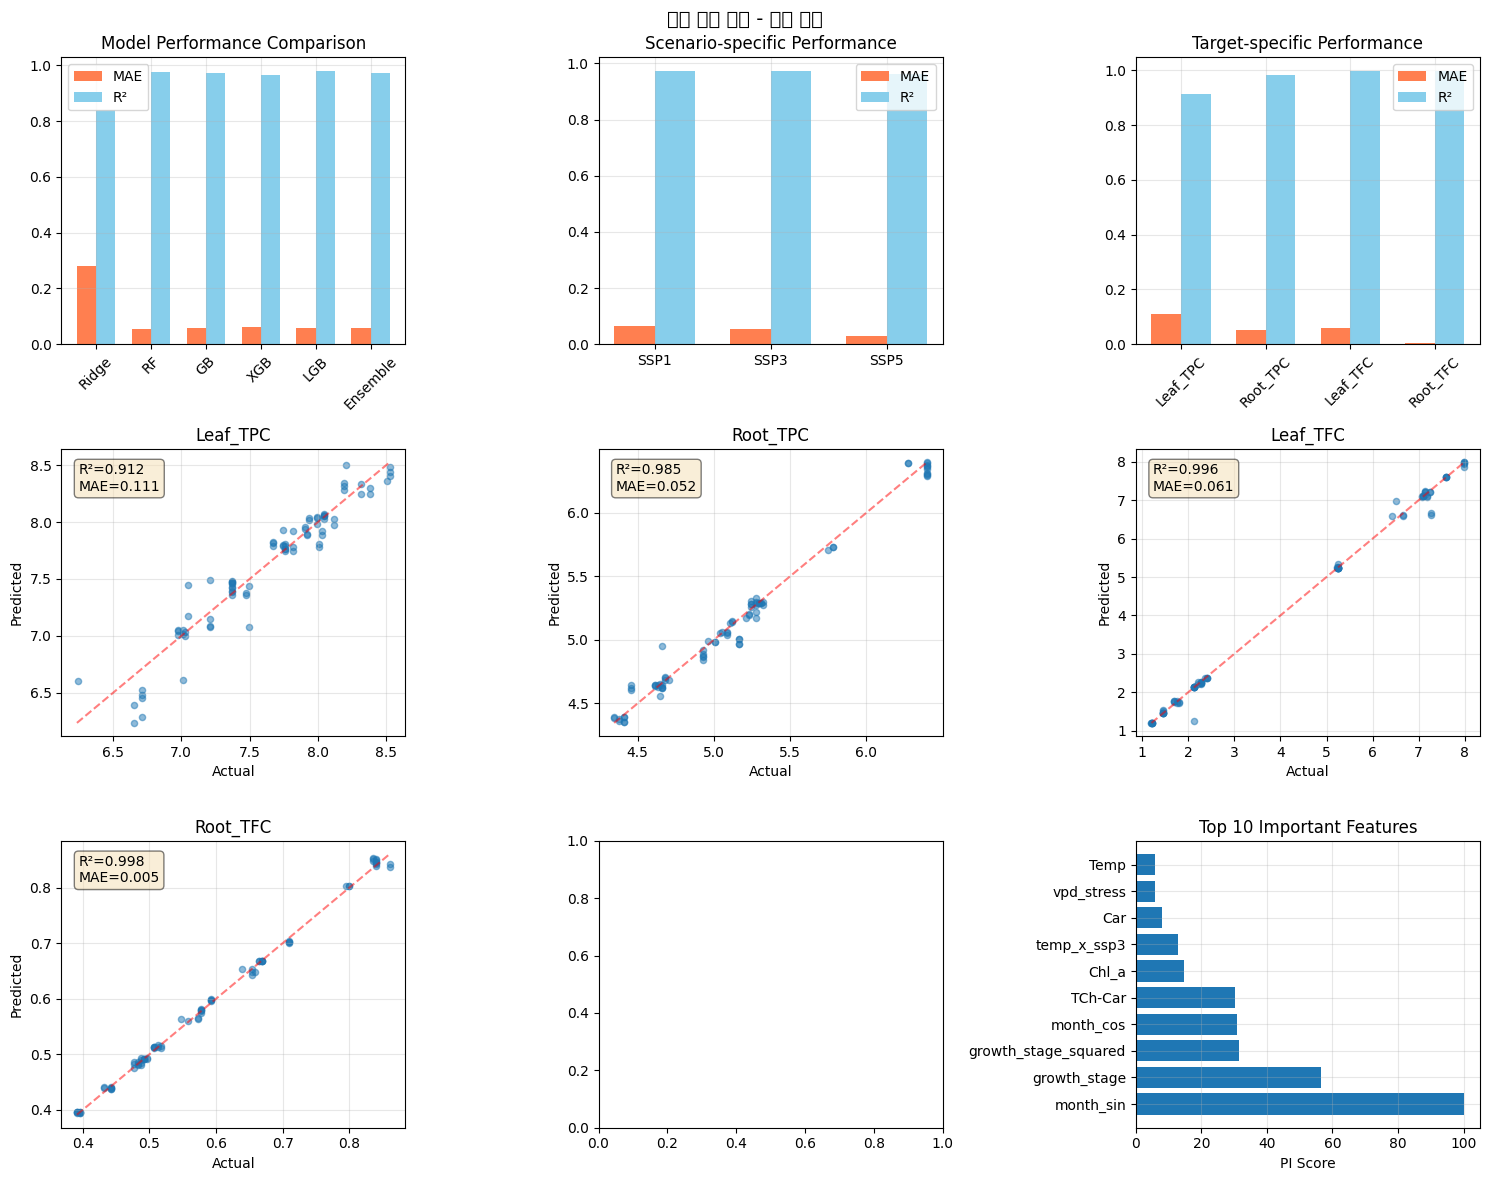

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# 1. 모델 성능 비교
ax = axes[0, 0]
model_names = list(global_results.keys()) + ['Ensemble']
mae_scores = [global_results[m]['MAE'] for m in global_results.keys()] + [ensemble_metrics['MAE']]
r2_scores = [global_results[m]['R2'] for m in global_results.keys()] + [ensemble_metrics['R2']]

x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width/2, mae_scores, width, label='MAE', color='coral')
ax.bar(x + width/2, r2_scores, width, label='R²', color='skyblue')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45)
ax.legend()
ax.set_title('Model Performance Comparison')
ax.grid(alpha=0.3)

# 2. 시나리오별 성능
ax = axes[0, 1]
scenarios_list = list(scenario_results.keys())
scenario_mae = [scenario_results[s]['MAE'] for s in scenarios_list]
scenario_r2 = [scenario_results[s]['R2'] for s in scenarios_list]

x = np.arange(len(scenarios_list))
ax.bar(x - width/2, scenario_mae, width, label='MAE', color='coral')
ax.bar(x + width/2, scenario_r2, width, label='R²', color='skyblue')
ax.set_xticks(x)
ax.set_xticklabels(scenarios_list)
ax.legend()
ax.set_title('Scenario-specific Performance')
ax.grid(alpha=0.3)

# 3. 타겟별 성능
ax = axes[0, 2]
target_names = list(target_results.keys())
target_mae = [target_results[t]['MAE'] for t in target_names]
target_r2 = [target_results[t]['R2'] for t in target_names]

x = np.arange(len(target_names))
ax.bar(x - width/2, target_mae, width, label='MAE', color='coral')
ax.bar(x + width/2, target_r2, width, label='R²', color='skyblue')
ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=45)
ax.legend()
ax.set_title('Target-specific Performance')
ax.grid(alpha=0.3)

# 4-7. 각 타겟별 예측 vs 실제
for i, target_col in enumerate(y_targets.columns):
    ax = axes[1, i] if i < 3 else axes[2, i-3]
    
    y_true = y_test[target_col].values
    y_pred = final_predictions[:, i]
    
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    
    # 완벽한 예측선
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
    
    # 성능 표시
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.text(0.05, 0.95, f'R²={r2:.3f}\nMAE={mae:.3f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(target_col)
    ax.grid(alpha=0.3)

# 8. 특성 중요도
ax = axes[2, 2]
top_10_features = importance_df.head(10)
ax.barh(range(10), top_10_features['PI_Score'].values)
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_features['Feature'].values)
ax.set_xlabel('PI Score')
ax.set_title('Top 10 Important Features')
ax.grid(alpha=0.3)

plt.suptitle('천궁 예측 모델 - 최종 결과', fontsize=14)
plt.tight_layout()

In [33]:
print("\n✅ 목표 1: 예측 모델 성능")
print(f"  MAE:   {ensemble_metrics['MAE']:.4f}")
print(f"  MSE:   {ensemble_metrics['MSE']:.4f}")
print(f"  RMSE:  {ensemble_metrics['RMSE']:.4f}")
print(f"  MSLE:  {ensemble_metrics['MSLE']:.4f}")
print(f"  RMSLE: {ensemble_metrics['RMSLE']:.4f}")


✅ 목표 1: 예측 모델 성능
  MAE:   0.0574
  MSE:   0.0135
  RMSE:  0.1161
  MSLE:  0.0006
  RMSLE: 0.0236
